# Minimal Example: Comparing the properties of the four TMAP grids

In this example script, we'll reproduce Figure 3 from the v2.5 release paper ([Jones et al. 2026](http://phoebe-project.org/publications/2026Jones+)).

Let's first make sure we have the latest version of PHOEBE 2.5 installed (uncomment this line if running in an online notebook session such as colab).

In [1]:
#!pip install -I "phoebe>=2.5"

In [1]:
import phoebe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams["font.size"] = 18
#rcParams["text.latex.preamble"] = r"\usepackage{cmbright}"
matplotlib.rcParams["savefig.dpi"] = 100
from phoebe.atmospheres import models
from phoebe.atmospheres.passbands import InterpQuery


In [2]:
logg=6.5 #6-6.5
teff=80000 #40-140kK
pb=phoebe.get_passband('SDSS:iprime')

In [3]:
DAloghefrac=np.array([-10.])
DAquery_pts=np.ascontiguousarray(np.array([teff*np.ones(len(DAloghefrac)),logg*np.ones(len(DAloghefrac)),DAloghefrac]).T)
DAquery_table=InterpQuery(cols=['teffs','loggs','loghefracs'],pts=np.c_[DAquery_pts])


DAlin=pb.interpolate_ldcoeffs(query=DAquery_table,ldatm=models.TMAPDAModelAtmosphere,ld_func='linear').get_interpolated_values()
DAInorm=pb.interpolate_inorms(query=DAquery_table, atm=models.TMAPDAModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

In [4]:
DAOloghefrac=pb.ndp['tmap_DAO'].axes[2]
DAOquery_pts=np.ascontiguousarray(np.array([teff*np.ones(len(DAOloghefrac)),logg*np.ones(len(DAOloghefrac)),DAOloghefrac]).T)
DAOquery_table=InterpQuery(cols=['teffs','loggs','loghefracs'],pts=np.c_[DAOquery_pts])


DAOlin=pb.interpolate_ldcoeffs(query=DAOquery_table,ldatm=models.TMAPDAOModelAtmosphere,ld_func='linear').get_interpolated_values()
DAOInorm=pb.interpolate_inorms(query=DAOquery_table, atm=models.TMAPDAOModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

In [5]:
DOloghefrac=np.array([9.4])
DOquery_pts=np.ascontiguousarray(np.array([teff*np.ones(len(DOloghefrac)),logg*np.ones(len(DOloghefrac)),DOloghefrac]).T)
DOquery_table=InterpQuery(cols=['teffs','loggs','loghefracs'],pts=np.c_[DOquery_pts])


DOlin=pb.interpolate_ldcoeffs(query=DOquery_table,ldatm=models.TMAPDOModelAtmosphere,ld_func='linear').get_interpolated_values()
DOInorm=pb.interpolate_inorms(query=DOquery_table, atm=models.TMAPDOModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

In [6]:
sdOloghefrac=pb.ndp['tmap_sdO'].axes[2]
sdOquery_pts=np.ascontiguousarray(np.array([teff*np.ones(len(sdOloghefrac)),logg*np.ones(len(sdOloghefrac)),sdOloghefrac]).T)
sdOquery_table=InterpQuery(cols=['teffs','loggs','loghefracs'],pts=np.c_[sdOquery_pts])


sdOlin=pb.interpolate_ldcoeffs(query=sdOquery_table,ldatm=models.TMAPsdOModelAtmosphere,ld_func='linear').get_interpolated_values()
sdOInorm=pb.interpolate_inorms(query=sdOquery_table, atm=models.TMAPsdOModelAtmosphere, ld_func='linear', ld_coeffs=[0.0]).get_interpolated_values()

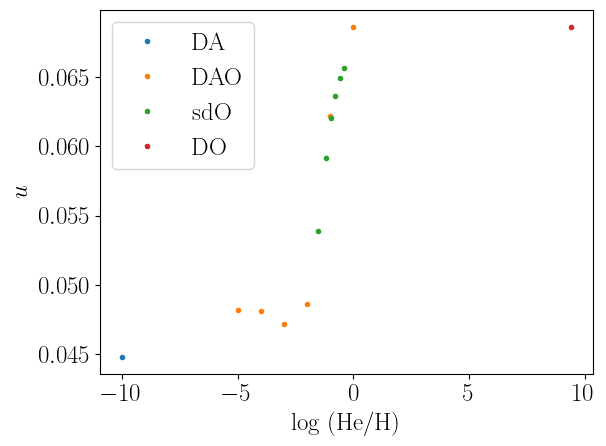

In [7]:
plt.plot(DAloghefrac,DAlin,ls='',marker='.',label="DA")
plt.plot(DAOloghefrac,DAOlin,ls='',marker='.',label="DAO")
plt.plot(sdOloghefrac,sdOlin,ls='',marker='.',label="sdO")
plt.plot(DOloghefrac,DOlin,ls='',marker='.',label="DO")
plt.legend()
plt.ylabel("$u$")
plt.xlabel("log (He/H)")
plt.tight_layout()


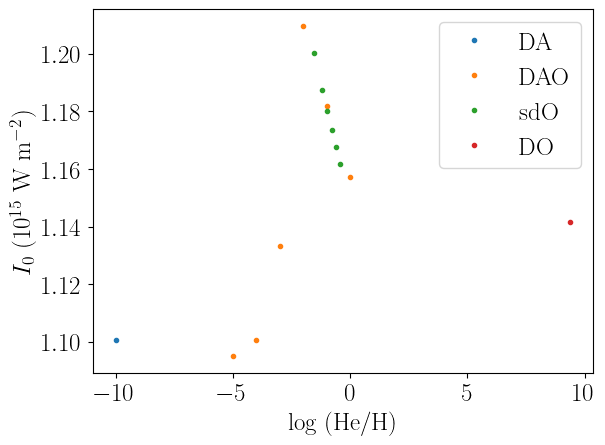

In [8]:
plt.plot(DAloghefrac,DAInorm/1e15,ls='',marker='.',label="DA")
plt.plot(DAOloghefrac,DAOInorm/1e15,ls='',marker='.',label="DAO")
plt.plot(sdOloghefrac,sdOInorm/1e15,ls='',marker='.',label="sdO")
plt.plot(DOloghefrac,DOInorm/1e15,ls='',marker='.',label="DO")
plt.legend()
plt.xlabel("log (He/H)")
plt.ylabel("$I_0$ (10$^{15}$ W m$^{-2}$)")
plt.tight_layout()
